<a href="https://colab.research.google.com/github/wyaamina/task1amina/blob/main/%D0%B4%D0%B8%D0%BF%D0%BB%D0%BE%D0%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

загрузка данных

In [1]:
import pandas as pd
regions = pd.read_excel(f'https://drive.google.com/uc?export=download&id=1ufGnuUecahhK175DObLdPViZoG2SX_6X', sheet_name='регионы')
regions_clear = pd.read_excel(f'https://drive.google.com/uc?export=download&id=1ufGnuUecahhK175DObLdPViZoG2SX_6X', sheet_name='регионы без выбросов')
print(regions.head())
print(regions_clear.head())
print (rf.head)


             Unnamed: 0         у         х1            x2         х3  \
0  Белгородская область  3.945306  56.590909  22681.571981  16.022087   
1      Брянская область  4.186814  56.227273  14229.799903  16.369369   
2  Владимирская область  4.289568  55.327273  21239.708860  16.040730   
3   Воронежская область  4.022543  56.554545  18118.363655  14.726366   
4    Ивановская область  4.319064  55.527273  19648.247084  15.588773   

         х4        х5         х6  Unnamed: 8  
0  7.361664  6.416277  12.997345           1  
1  8.325928  6.730243   9.862599           2  
2  7.155343  6.227884   8.989009           3  
3  7.504394  6.431388  15.605299           4  
4  7.310381  6.090290  11.878408           5  
             Unnamed: 0         у         х1            x2         х3  \
0  Белгородская область  3.945306  56.590909  22681.571981  16.022087   
1      Брянская область  4.186814  56.227273  14229.799903  16.369369   
2  Владимирская область  4.289568  55.327273  21239.708860  


корреляционный анализ

In [2]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy import stats

cols = regions.iloc[:, 1:8]
column_names = cols.columns.tolist()
n_vars = len(column_names)

# Инициализация матриц для каждого типа корреляции и p-values
pearson_matrix = pd.DataFrame(np.nan, index=column_names, columns=column_names)
pearson_p_matrix = pd.DataFrame(np.nan, index=column_names, columns=column_names)
pearson_sig_matrix = pd.DataFrame('', index=column_names, columns=column_names)

spearman_matrix = pd.DataFrame(np.nan, index=column_names, columns=column_names)
spearman_p_matrix = pd.DataFrame(np.nan, index=column_names, columns=column_names)
spearman_sig_matrix = pd.DataFrame('', index=column_names, columns=column_names)

kendall_matrix = pd.DataFrame(np.nan, index=column_names, columns=column_names)
kendall_p_matrix = pd.DataFrame(np.nan, index=column_names, columns=column_names)
kendall_sig_matrix = pd.DataFrame('', index=column_names, columns=column_names)

# Матрица количества наблюдений
n_matrix = pd.DataFrame(np.nan, index=column_names, columns=column_names)

# Заполнение матриц
for col1, col2 in combinations(column_names, 2):
    valid_data = regions[[col1, col2]].dropna()
    n = len(valid_data)

    # Корреляции
    pearson = valid_data[col1].corr(valid_data[col2], method='pearson')
    spearman = valid_data[col1].corr(valid_data[col2], method='spearman')
    kendall = valid_data[col1].corr(valid_data[col2], method='kendall')

    # Проверка значимости (p-value)
    alpha = 0.05

    # Пирсон
    if n > 2:
        pearson_r, pearson_p = stats.pearsonr(valid_data[col1], valid_data[col2])
        pearson_sig = 'Да' if pearson_p < alpha else 'Нет'
    else:
        pearson_p = np.nan
        pearson_sig = 'Н/Д'

    # Спирмен
    if n > 2:
        spearman_r, spearman_p = stats.spearmanr(valid_data[col1], valid_data[col2])
        spearman_sig = 'Да' if spearman_p < alpha else 'Нет'
    else:
        spearman_p = np.nan
        spearman_sig = 'Н/Д'

    # Кендалл
    if n > 2:
        kendall_tau, kendall_p = stats.kendalltau(valid_data[col1], valid_data[col2])
        kendall_sig = 'Да' if kendall_p < alpha else 'Нет'
    else:
        kendall_p = np.nan
        kendall_sig = 'Н/Д'

    pearson_matrix.loc[col1, col2] = pearson
    pearson_matrix.loc[col2, col1] = pearson
    pearson_p_matrix.loc[col1, col2] = pearson_p
    pearson_p_matrix.loc[col2, col1] = pearson_p
    pearson_sig_matrix.loc[col1, col2] = pearson_sig
    pearson_sig_matrix.loc[col2, col1] = pearson_sig

    spearman_matrix.loc[col1, col2] = spearman
    spearman_matrix.loc[col2, col1] = spearman
    spearman_p_matrix.loc[col1, col2] = spearman_p
    spearman_p_matrix.loc[col2, col1] = spearman_p
    spearman_sig_matrix.loc[col1, col2] = spearman_sig
    spearman_sig_matrix.loc[col2, col1] = spearman_sig

    kendall_matrix.loc[col1, col2] = kendall
    kendall_matrix.loc[col2, col1] = kendall
    kendall_p_matrix.loc[col1, col2] = kendall_p
    kendall_p_matrix.loc[col2, col1] = kendall_p
    kendall_sig_matrix.loc[col1, col2] = kendall_sig
    kendall_sig_matrix.loc[col2, col1] = kendall_sig

    n_matrix.loc[col1, col2] = n
    n_matrix.loc[col2, col1] = n

for var in column_names:
    pearson_matrix.loc[var, var] = 1.0
    spearman_matrix.loc[var, var] = 1.0
    kendall_matrix.loc[var, var] = 1.0
    pearson_p_matrix.loc[var, var] = 0.0
    spearman_p_matrix.loc[var, var] = 0.0
    kendall_p_matrix.loc[var, var] = 0.0
    pearson_sig_matrix.loc[var, var] = '-'
    spearman_sig_matrix.loc[var, var] = '-'
    kendall_sig_matrix.loc[var, var] = '-'
    n_matrix.loc[var, var] = len(regions[var].dropna())

print("="*80)
print("МАТРИЦА КОРРЕЛЯЦИЙ ПИРСОНА")
print("="*80)
print(pearson_matrix.round(3))
print("\n")

print("="*80)
print("МАТРИЦА КОРРЕЛЯЦИЙ СПИРМЕНА")
print("="*80)
print(spearman_matrix.round(3))
print("\n")

print("="*80)
print("МАТРИЦА КОРРЕЛЯЦИЙ КЕНДАЛЛА")
print("="*80)
print(kendall_matrix.round(3))
print("\n")

with pd.ExcelWriter('корреляционные_матрицы.xlsx') as writer:
    pearson_matrix.to_excel(writer, sheet_name='Пирсон_коэф')
    pearson_p_matrix.to_excel(writer, sheet_name='Пирсон_p-value')
    pearson_sig_matrix.to_excel(writer, sheet_name='Пирсон_значимость')

    spearman_matrix.to_excel(writer, sheet_name='Спирмен_коэф')
    spearman_p_matrix.to_excel(writer, sheet_name='Спирмен_p-value')
    spearman_sig_matrix.to_excel(writer, sheet_name='Спирмен_значимость')

    kendall_matrix.to_excel(writer, sheet_name='Кендалл_коэф')
    kendall_p_matrix.to_excel(writer, sheet_name='Кендалл_p-value')
    kendall_sig_matrix.to_excel(writer, sheet_name='Кендалл_значимость')

    n_matrix.to_excel(writer, sheet_name='Количество_наблюдений')

from google.colab import files
files.download('корреляционные_матрицы.xlsx')

МАТРИЦА КОРРЕЛЯЦИЙ ПИРСОНА
        у     х1     x2     х3     х4     х5     х6
у   1.000  0.133 -0.312  0.531  0.280  0.077 -0.261
х1  0.133  1.000  0.228 -0.168  0.113 -0.532 -0.122
x2 -0.312  0.228  1.000 -0.061  0.101 -0.227 -0.166
х3  0.531 -0.168 -0.061  1.000  0.703  0.439 -0.408
х4  0.280  0.113  0.101  0.703  1.000  0.199 -0.223
х5  0.077 -0.532 -0.227  0.439  0.199  1.000  0.167
х6 -0.261 -0.122 -0.166 -0.408 -0.223  0.167  1.000


МАТРИЦА КОРРЕЛЯЦИЙ СПИРМЕНА
        у     х1     x2     х3     х4     х5     х6
у   1.000 -0.024 -0.284  0.591  0.347  0.208 -0.234
х1 -0.024  1.000  0.199 -0.193 -0.011 -0.436 -0.087
x2 -0.284  0.199  1.000 -0.101  0.179 -0.232 -0.070
х3  0.591 -0.193 -0.101  1.000  0.674  0.354 -0.404
х4  0.347 -0.011  0.179  0.674  1.000  0.069 -0.253
х5  0.208 -0.436 -0.232  0.354  0.069  1.000  0.283
х6 -0.234 -0.087 -0.070 -0.404 -0.253  0.283  1.000


МАТРИЦА КОРРЕЛЯЦИЙ КЕНДАЛЛА
        у     х1     x2     х3     х4     х5     х6
у   1.000 -0.011 -0.203  0.42

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

робастное статистическое оценивание

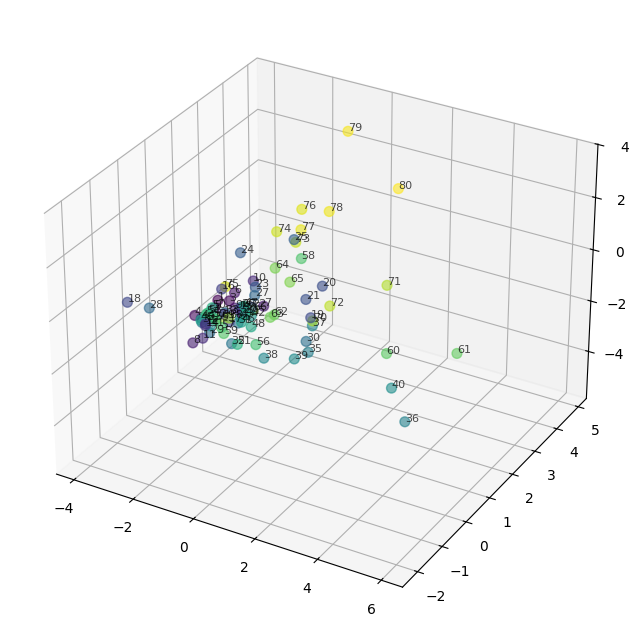

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

yx = regions.iloc[:, 1:8].values
scaler = StandardScaler()
yx_scaled = scaler.fit_transform(yx)

pca = PCA(n_components=3)
yx_pca = pca.fit_transform(yx_scaled)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(yx_pca[:, 0], yx_pca[:, 1], yx_pca[:, 2],
                     c=range(len(yx_pca)), cmap='viridis', s=50, alpha=0.6)

for i in range(len(yx_pca)):
    ax.text(yx_pca[i, 0], yx_pca[i, 1], yx_pca[i, 2],
            str(i+1),
            fontsize=8,
            alpha=0.7)

проверка регионов методом хотеллинга

In [5]:
import numpy as np
import pandas as pd
from scipy import stats

data_hotelling = regions.iloc[:, 1:8].values
mean_vector = np.mean(data_hotelling, axis=0)  # средний вектор всей выборки
cov_matrix = np.cov(data_hotelling, rowvar=False)  # ковариационная матрица
inv_cov = np.linalg.pinv(cov_matrix)  # обратная ковариационная матрица
n = data_hotelling.shape[0]  # количество строк
p = data_hotelling.shape[1]  # количество переменных

results = []
for i in range(n):
    diff = data_hotelling[i] - mean_vector
    t2 = n * diff @ inv_cov @ diff.T  # статистика T²
    # F-статистика и p-value
    f_stat = (n - p) / (p * (n - 1)) * t2
    p_value = 1 - stats.f.cdf(f_stat, p, n - p)
    results.append({
        'Строка': i,
        'T²': t2,
        'F_stat': f_stat,
        'p_value': p_value,
        'отличается_от_средней': p_value < 0.05
    })

results_df = pd.DataFrame(results)
print(results_df)
results_df.to_excel('хоттелинга.xlsx', index=False)
files.download('хоттелинга.xlsx')

    Строка           T²      F_stat       p_value  отличается_от_средней
0        0    96.986736   12.802951  1.303089e-10                   True
1        1   102.089908   13.476606  4.845113e-11                   True
2        2   145.206801   19.168348  2.775558e-14                   True
3        3   177.165204   23.387088  2.220446e-16                   True
4        4   135.632282   17.904442  1.287859e-13                   True
..     ...          ...         ...           ...                    ...
75      75  1527.841995  201.686195  1.110223e-16                   True
76      76   560.777345   74.026666  1.110223e-16                   True
77      77   535.196328   70.649786  1.110223e-16                   True
78      78  3447.662714  455.116416  1.110223e-16                   True
79      79  1952.781185  257.781241  1.110223e-16                   True

[80 rows x 5 columns]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

определение количества кластеров

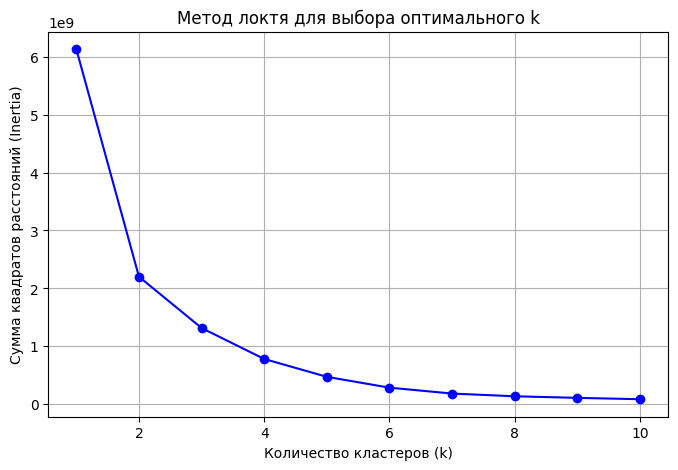

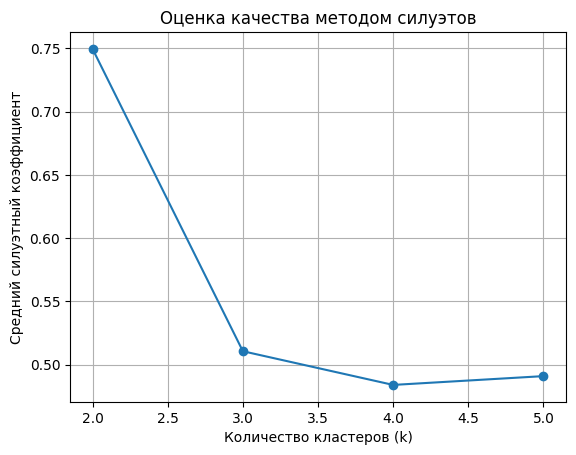

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

data_clusstering = regions_clear.iloc[:, 1:8].values

inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(data_clusstering)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='b')
plt.title('Метод локтя для выбора оптимального k')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний (Inertia)')
plt.grid(True)
plt.show()

silhouette_scores = []
K_range = range(2, 6)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(data_clusstering)
    score = silhouette_score(data_clusstering, labels)
    silhouette_scores.append(score)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Оценка качества методом силуэтов')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Средний силуэтный коэффициент')
plt.grid(True)
plt.show()

кластерные модели и проверка качества методом хотеллинга

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from google.colab import files
import subprocess
import sys
from scipy import stats

def install_skfuzzy():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-fuzzy"])
install_skfuzzy()
import skfuzzy as fuzz

region_names = regions_clear.iloc[:, 0].values
data_clussters = regions_clear.iloc[:, 1:8].values
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clussters)

n_clusters = 3

# Функция для расчета T² Хотеллинга между двумя кластерами
def hotelling_t2_test(cluster1, cluster2):
    """
    Двухвыборочный T²-критерий Хотеллинга для проверки различий между кластерами
    """
    n1, n2 = len(cluster1), len(cluster2)

    if n1 <= 1 or n2 <= 1:
        return np.nan, np.nan

    p = cluster1.shape[1]  # количество признаков

    # Средние векторы
    mean1 = cluster1.mean(axis=0)
    mean2 = cluster2.mean(axis=0)

    # Ковариационные матрицы
    cov1 = np.cov(cluster1.T)
    cov2 = np.cov(cluster2.T)

    # Объединенная ковариационная матрица
    pooled_cov = ((n1 - 1) * cov1 + (n2 - 1) * cov2) / (n1 + n2 - 2)

    try:
        inv_pooled_cov = np.linalg.pinv(pooled_cov)  # псевдообратная для устойчивости
    except:
        return np.nan, np.nan

    # Разность средних
    diff = mean1 - mean2

    # Статистика Хотеллинга T²
    t2 = (n1 * n2) / (n1 + n2) * np.dot(np.dot(diff, inv_pooled_cov), diff)

    # Преобразование в F-статистику
    f_stat = (n1 + n2 - p - 1) / ((n1 + n2 - 2) * p) * t2

    # p-значение
    p_value = 1 - stats.f.cdf(f_stat, p, n1 + n2 - p - 1)

    return t2, p_value

def euclidean_dist(x, y):
    return np.sqrt(np.sum((x - y)**2))

# Метод ближайшего соседа
Z_single = sch.linkage(data_scaled, method='single')
clusters_single = fcluster(Z_single, n_clusters, criterion='maxclust')

# Метод дальнего соседа
Z_complete = sch.linkage(data_scaled, method='complete')
clusters_complete = fcluster(Z_complete, n_clusters, criterion='maxclust')

# Метод группового среднего
Z_average = sch.linkage(data_scaled, method='average')
clusters_average = fcluster(Z_average, n_clusters, criterion='maxclust')

# Медианный метод
Z_median = sch.linkage(data_scaled, method='median')
clusters_median = fcluster(Z_median, n_clusters, criterion='maxclust')

# Метод Уорда
Z_ward = sch.linkage(data_scaled, method='ward')
clusters_ward = fcluster(Z_ward, n_clusters, criterion='maxclust')

# K-means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(data_scaled) + 1

# FCM
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data_scaled.T, n_clusters, 2, error=0.005, maxiter=1000, init=None
)
clusters_fcm = np.argmax(u, axis=0) + 1

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=3)
clusters_dbscan = dbscan.fit_predict(data_scaled)
clusters_dbscan = clusters_dbscan + 2

# GMM
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
clusters_gmm = gmm.fit_predict(data_scaled) + 1

# Анализ методом Хотеллинга для каждого метода кластеризации
methods = {
    'Ближайший_сосед': clusters_single,
    'Дальний_сосед': clusters_complete,
    'Групповое_среднее': clusters_average,
    'Медианный': clusters_median,
    'Уорд': clusters_ward,
    'K-means': clusters_kmeans,
    'FCM': clusters_fcm,
    'DBSCAN': clusters_dbscan,
    'GMM': clusters_gmm
}

print("\n" + "="*70)
print("МЕТОД ХОТЕЛЛИНГА: ПРОВЕРКА СТАТИСТИЧЕСКИХ РАЗЛИЧИЙ МЕЖДУ КЛАСТЕРАМИ")
print("="*70)

results_summary = []

for method_name, clusters in methods.items():
    print(f"\n{method_name}:")
    print("-" * 50)

    unique_clusters = np.unique(clusters)
    cluster_data = {}

    for cl in unique_clusters:
        cluster_data[cl] = data_scaled[clusters == cl]
        print(f"  Кластер {cl}: n={len(cluster_data[cl])} объектов")

    print("\n  Результаты попарного сравнения (T²-критерий Хотеллинга):")
    print("  " + "-" * 45)

    significant_count = 0
    comparisons = []

    for i in range(len(unique_clusters)):
        for j in range(i+1, len(unique_clusters)):
            cl1 = unique_clusters[i]
            cl2 = unique_clusters[j]

            t2, p_value = hotelling_t2_test(cluster_data[cl1], cluster_data[cl2])

            if not np.isnan(p_value):
                is_significant = p_value < 0.05
                if is_significant:
                    significant_count += 1

                comparisons.append({
                    'Метод': method_name,
                    'Сравнение': f"К{cl1} vs К{cl2}",
                    'T²': t2,
                    'p-значение': p_value,
                    'Значимо (p<0.05)': 'ДА' if is_significant else 'нет'
                })

                status = "✓ ЗНАЧИМО" if is_significant else "✗ не значимо"
                print(f"    К{cl1} vs К{cl2}: T² = {t2:.3f}, p = {p_value:.4f} -> {status}")

    print(f"\n  ИТОГ: {significant_count} из {len(comparisons)} сравнений статистически значимы")

    if significant_count == 0:
        print("  ВЫВОД: Кластеры статистически неразличимы → модель не валидна")
    elif significant_count == len(comparisons):
        print("  ВЫВОД: Все кластеры статистически различны → хорошая модель")
    else:
        print("  ВЫВОД: Часть кластеров статистически неразличима → требуется оптимизация")

# Итоговая таблица
print("\n" + "="*70)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ")
print("="*70)

clussters = pd.DataFrame({
    'Название_региона': region_names,
    'Ближайший_сосед': clusters_single,
    'Дальний_сосед': clusters_complete,
    'Групповое_среднее': clusters_average,
    'Медианный': clusters_median,
    'Уорд': clusters_ward,
    'K-means': clusters_kmeans,
    'FCM': clusters_fcm,
    'DBSCAN': clusters_dbscan,
    'GMM': clusters_gmm
})

print(clussters)

clussters.to_excel('результаты_кластеризации.xlsx', index=False)
files.download('результаты_кластеризации.xlsx')


МЕТОД ХОТЕЛЛИНГА: ПРОВЕРКА СТАТИСТИЧЕСКИХ РАЗЛИЧИЙ МЕЖДУ КЛАСТЕРАМИ

Ближайший_сосед:
--------------------------------------------------
  Кластер 1: n=3 объектов
  Кластер 2: n=67 объектов
  Кластер 3: n=1 объектов

  Результаты попарного сравнения (T²-критерий Хотеллинга):
  ---------------------------------------------
    К1 vs К2: T² = 127.743, p = 0.0000 -> ✓ ЗНАЧИМО

  ИТОГ: 1 из 1 сравнений статистически значимы
  ВЫВОД: Все кластеры статистически различны → хорошая модель

Дальний_сосед:
--------------------------------------------------
  Кластер 1: n=2 объектов
  Кластер 2: n=7 объектов
  Кластер 3: n=62 объектов

  Результаты попарного сравнения (T²-критерий Хотеллинга):
  ---------------------------------------------
    К1 vs К2: T² = 547.132, p = 0.2266 -> ✗ не значимо
    К1 vs К3: T² = 83.390, p = 0.0000 -> ✓ ЗНАЧИМО
    К2 vs К3: T² = 208.948, p = 0.0000 -> ✓ ЗНАЧИМО

  ИТОГ: 2 из 3 сравнений статистически значимы
  ВЫВОД: Часть кластеров статистически неразличима → 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>